# 🍼 Bottle Detection with Outline & Cropping

This notebook:
1. Detects bottles using YOLOv8
2. **Draws outlines** (contours) around each bottle
3. **Crops only the outlined region** (removes background)
4. Maintains your **damaged / not_damaged** folder structure

---

## Step 1: Install Dependencies (Fixed Versions)

In [1]:
# Fix dependency conflicts first
!pip uninstall -y pillow -q
!pip install pillow==10.4.0 -q

# Install YOLOv8 with compatible versions
!pip install ultralytics==8.2.0 -q

print("✅ Dependencies installed!")
print("⚠️ If you see warnings above, they can be ignored.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 26.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 18.2 MB/s eta 0:00:00
✅ Dependencies installed!
⚠️ If you see warnings above, they can be ignored.


In [2]:
# Import libraries
import os
import cv2
import zipfile
import numpy as np
from pathlib import Path
from google.colab import files
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

print("✅ All imports successful!")

✅ All imports successful!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Upload Your bottles.zip File

In [4]:
# # Upload your bottles.zip file
# print("📁 Please upload your bottles.zip file...")
# print("   Expected structure:")
# print("   bottles.zip")
# print("   ├── damaged/")
# print("   │   ├── img1.jpg")
# print("   │   └── ...")
# print("   └── not_damaged/")
# print("       ├── img1.jpg")
# print("       └── ...")
# print()

# uploaded = files.upload()
# zip_filename = list(uploaded.keys())[0]
# print(f"\n✅ Uploaded: {zip_filename}")
# Use bottles.zip already uploaded to Colab
import os

# Option 1: If you uploaded to /content/

zip_filename='/content/drive/MyDrive/edge/dataset.zip'
# zip_filename = "/content/dataset.zip"

# Option 2: If you uploaded to Google Drive, uncomment below:
# from google.colab import drive
# drive.mount('/content/drive')
# zip_filename = "/content/drive/MyDrive/bottles.zip"  # Adjust path as needed

# Verify file exists
if os.path.exists(zip_filename):
    print(f"✅ Found: {zip_filename}")
    print(f"   Size: {os.path.getsize(zip_filename) / (1024*1024):.1f} MB")
else:
    print(f"❌ File not found: {zip_filename}")
    print("   Please upload bottles.zip to /content/ first")

✅ Found: /content/drive/MyDrive/edge/dataset.zip
   Size: 1021.8 MB


In [5]:
import shutil

# Extract the zip file
extract_dir = "bottles_dataset"

# Remove if exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ Extracted to: {extract_dir}/")

# Clean up the extracted structure:
# If there's a single 'dataset' folder inside, move its contents up
# and remove the empty 'dataset' folder.
dataset_subfolder = os.path.join(extract_dir, 'dataset')
if os.path.exists(dataset_subfolder) and os.path.isdir(dataset_subfolder):
    print(f"🔄 Moving contents of {dataset_subfolder}/ to {extract_dir}/")
    for item in os.listdir(dataset_subfolder):
        shutil.move(os.path.join(dataset_subfolder, item), extract_dir)
    shutil.rmtree(dataset_subfolder)

# Remove __MACOSX folder if it exists
macosx_folder = os.path.join(extract_dir, '__MACOSX')
if os.path.exists(macosx_folder) and os.path.isdir(macosx_folder):
    print(f"🗑️ Removing {macosx_folder}/")
    shutil.rmtree(macosx_folder)


# List contents and find folder structure
print("\n📂 Contents:")
for root, dirs, files_list in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    if folder_name:
        print(f"{indent}📁 {folder_name}/")
    # Count images
    img_files = [f for f in files_list if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if img_files:
        sub_indent = '  ' * (level + 1)
        print(f"{sub_indent}📷 {len(img_files)} images")

✅ Extracted to: bottles_dataset/
🔄 Moving contents of bottles_dataset/dataset/ to bottles_dataset/
🗑️ Removing bottles_dataset/__MACOSX/

📂 Contents:
📁 bottles_dataset/
  📁 non_damaged/
    📷 194 images
  📁 damaged/
    📷 877 images


In [6]:
# Find damaged and not_damaged folders
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Auto-detect folder structure
damaged_images = []
not_damaged_images = []

for root, dirs, files_list in os.walk(extract_dir):
    # Check current folder and parent folder names
    folder_name = os.path.basename(root).lower().replace('_', '').replace('-', '').replace(' ', '')
    parent_name = os.path.basename(os.path.dirname(root)).lower().replace('_', '').replace('-', '').replace(' ', '')

    for file in files_list:
        if Path(file).suffix.lower() in image_extensions:
            full_path = os.path.join(root, file)

            # Categorize based on folder name
            # Check for "not damaged" / "notdamaged" / "undamaged" / "good"
            is_not_damaged = any(x in folder_name for x in ['nondamaged', 'undamage', 'good', 'ok', 'normal']) or \
                             any(x in parent_name for x in ['nondamaged', 'undamage', 'good', 'ok', 'normal'])

            is_damaged = ('damage' in folder_name or 'damage' in parent_name) and not is_not_damaged

            if is_not_damaged:
                not_damaged_images.append(full_path)
            elif is_damaged:
                damaged_images.append(full_path)
            else:
                # Default: check if path contains hints
                path_lower = full_path.lower()
                if 'not' in path_lower or 'good' in path_lower:
                    not_damaged_images.append(full_path)
                elif 'damage' in path_lower:
                    damaged_images.append(full_path)

print(f"✅ Found images:")
print(f"   Damaged: {len(damaged_images)}")
print(f"   Not Damaged: {len(not_damaged_images)}")

# If nothing found, try simpler approach
if len(damaged_images) == 0 and len(not_damaged_images) == 0:
    print("\n⚠️ Could not auto-detect folder structure.")
    print("   Listing all found folders:")
    for root, dirs, _ in os.walk(extract_dir):
        for d in dirs:
            full_dir = os.path.join(root, d)
            img_count = len([f for f in os.listdir(full_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            if img_count > 0:
                print(f"   - {d}: {img_count} images")

# Combine all with labels
all_images = [
    {'path': p, 'label': 'damaged'} for p in damaged_images
] + [
    {'path': p, 'label': 'not_damaged'} for p in not_damaged_images
]

print(f"\n   Total: {len(all_images)} images")

# Show samples
if damaged_images:
    print(f"\n📁 Sample damaged: {os.path.basename(damaged_images[0])}")
if not_damaged_images:
    print(f"📁 Sample not_damaged: {os.path.basename(not_damaged_images[0])}")

✅ Found images:
   Damaged: 877
   Not Damaged: 194

   Total: 1071 images

📁 Sample damaged: bottle_164t 2.jpg
📁 Sample not_damaged: bottle_100t.jpg


## Step 3: Load YOLOv8 Model

In [7]:
# Fix for PyTorch 2.6+ weights_only security change
import torch

# Set weights_only=False for loading YOLO models
import ultralytics.nn.tasks as tasks
import torch.serialization

# Add safe globals for YOLO
torch.serialization.add_safe_globals([tasks.DetectionModel])

# Alternative: Monkey-patch torch.load (if above doesn't work)
_original_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

print("✅ PyTorch loading patched for YOLO compatibility")

✅ PyTorch loading patched for YOLO compatibility


In [8]:
# Load pre-trained YOLOv8 model
print("🔄 Loading YOLOv8 model...")
model = YOLO('yolov8n.pt')
print("✅ Model loaded!")
print("\n🍼 'bottle' is class ID: 39")

🔄 Loading YOLOv8 model...


100%|██████████| 6.23M/6.23M [00:00<00:00, 116MB/s]

✅ Model loaded!

🍼 'bottle' is class ID: 39


## Step 4: Define Outline & Cropping Functions

In [9]:
def get_bottle_mask_grabcut(image, bbox):
    """
    Create a mask for the bottle region using GrabCut.
    """
    x1, y1, x2, y2 = bbox
    height, width = image.shape[:2]

    # Ensure bbox is within image bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(width, x2), min(height, y2)

    # Check valid bbox
    if x2 <= x1 or y2 <= y1:
        mask = np.zeros(image.shape[:2], np.uint8)
        return mask

    # GrabCut for precise segmentation
    mask = np.zeros(image.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    rect = (x1, y1, x2 - x1, y2 - y1)

    try:
        cv2.grabCut(image, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    except Exception as e:
        # Fallback to simple rectangle mask
        mask = np.zeros(image.shape[:2], np.uint8)
        mask[y1:y2, x1:x2] = 1

    return mask


def get_bottle_contour(image, bbox):
    """
    Get the contour (outline) of a bottle.

    Returns:
        contour: The bottle contour points
        mask: Binary mask of the bottle
    """
    x1, y1, x2, y2 = bbox

    # Get mask using GrabCut
    mask = get_bottle_mask_grabcut(image, bbox)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Get largest contour (the bottle)
        contour = max(contours, key=cv2.contourArea)
        return contour, mask
    else:
        # Fallback: create rectangular contour from bbox
        contour = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]])
        return contour.reshape(-1, 1, 2), mask


def draw_bottle_outline(image, contour, color=(0, 255, 0), thickness=2):
    """
    Draw outline around the bottle.
    """
    outlined = image.copy()
    cv2.drawContours(outlined, [contour], -1, color, thickness)
    return outlined


def crop_bottle_with_contour(image, contour, mask, padding=10, fill_color=(255, 255, 255)):
    """
    Crop the bottle using contour mask.
    Background outside contour is set to fill_color.

    Returns:
        Cropped image with background removed
    """
    # Get bounding rect of contour
    x, y, w, h = cv2.boundingRect(contour)

    # Add padding
    height, width = image.shape[:2]
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(width, x + w + padding)
    y2 = min(height, y + h + padding)

    # Crop image and mask
    cropped_img = image[y1:y2, x1:x2].copy()
    cropped_mask = mask[y1:y2, x1:x2].copy()

    # Apply mask - set background to fill_color
    background = np.full_like(cropped_img, fill_color)
    mask_3ch = np.stack([cropped_mask] * 3, axis=-1)
    result = np.where(mask_3ch == 1, cropped_img, background)

    return result.astype(np.uint8), cropped_mask


print("✅ Functions defined!")

✅ Functions defined!


## Step 5: Test on Sample Images - Show Outlines

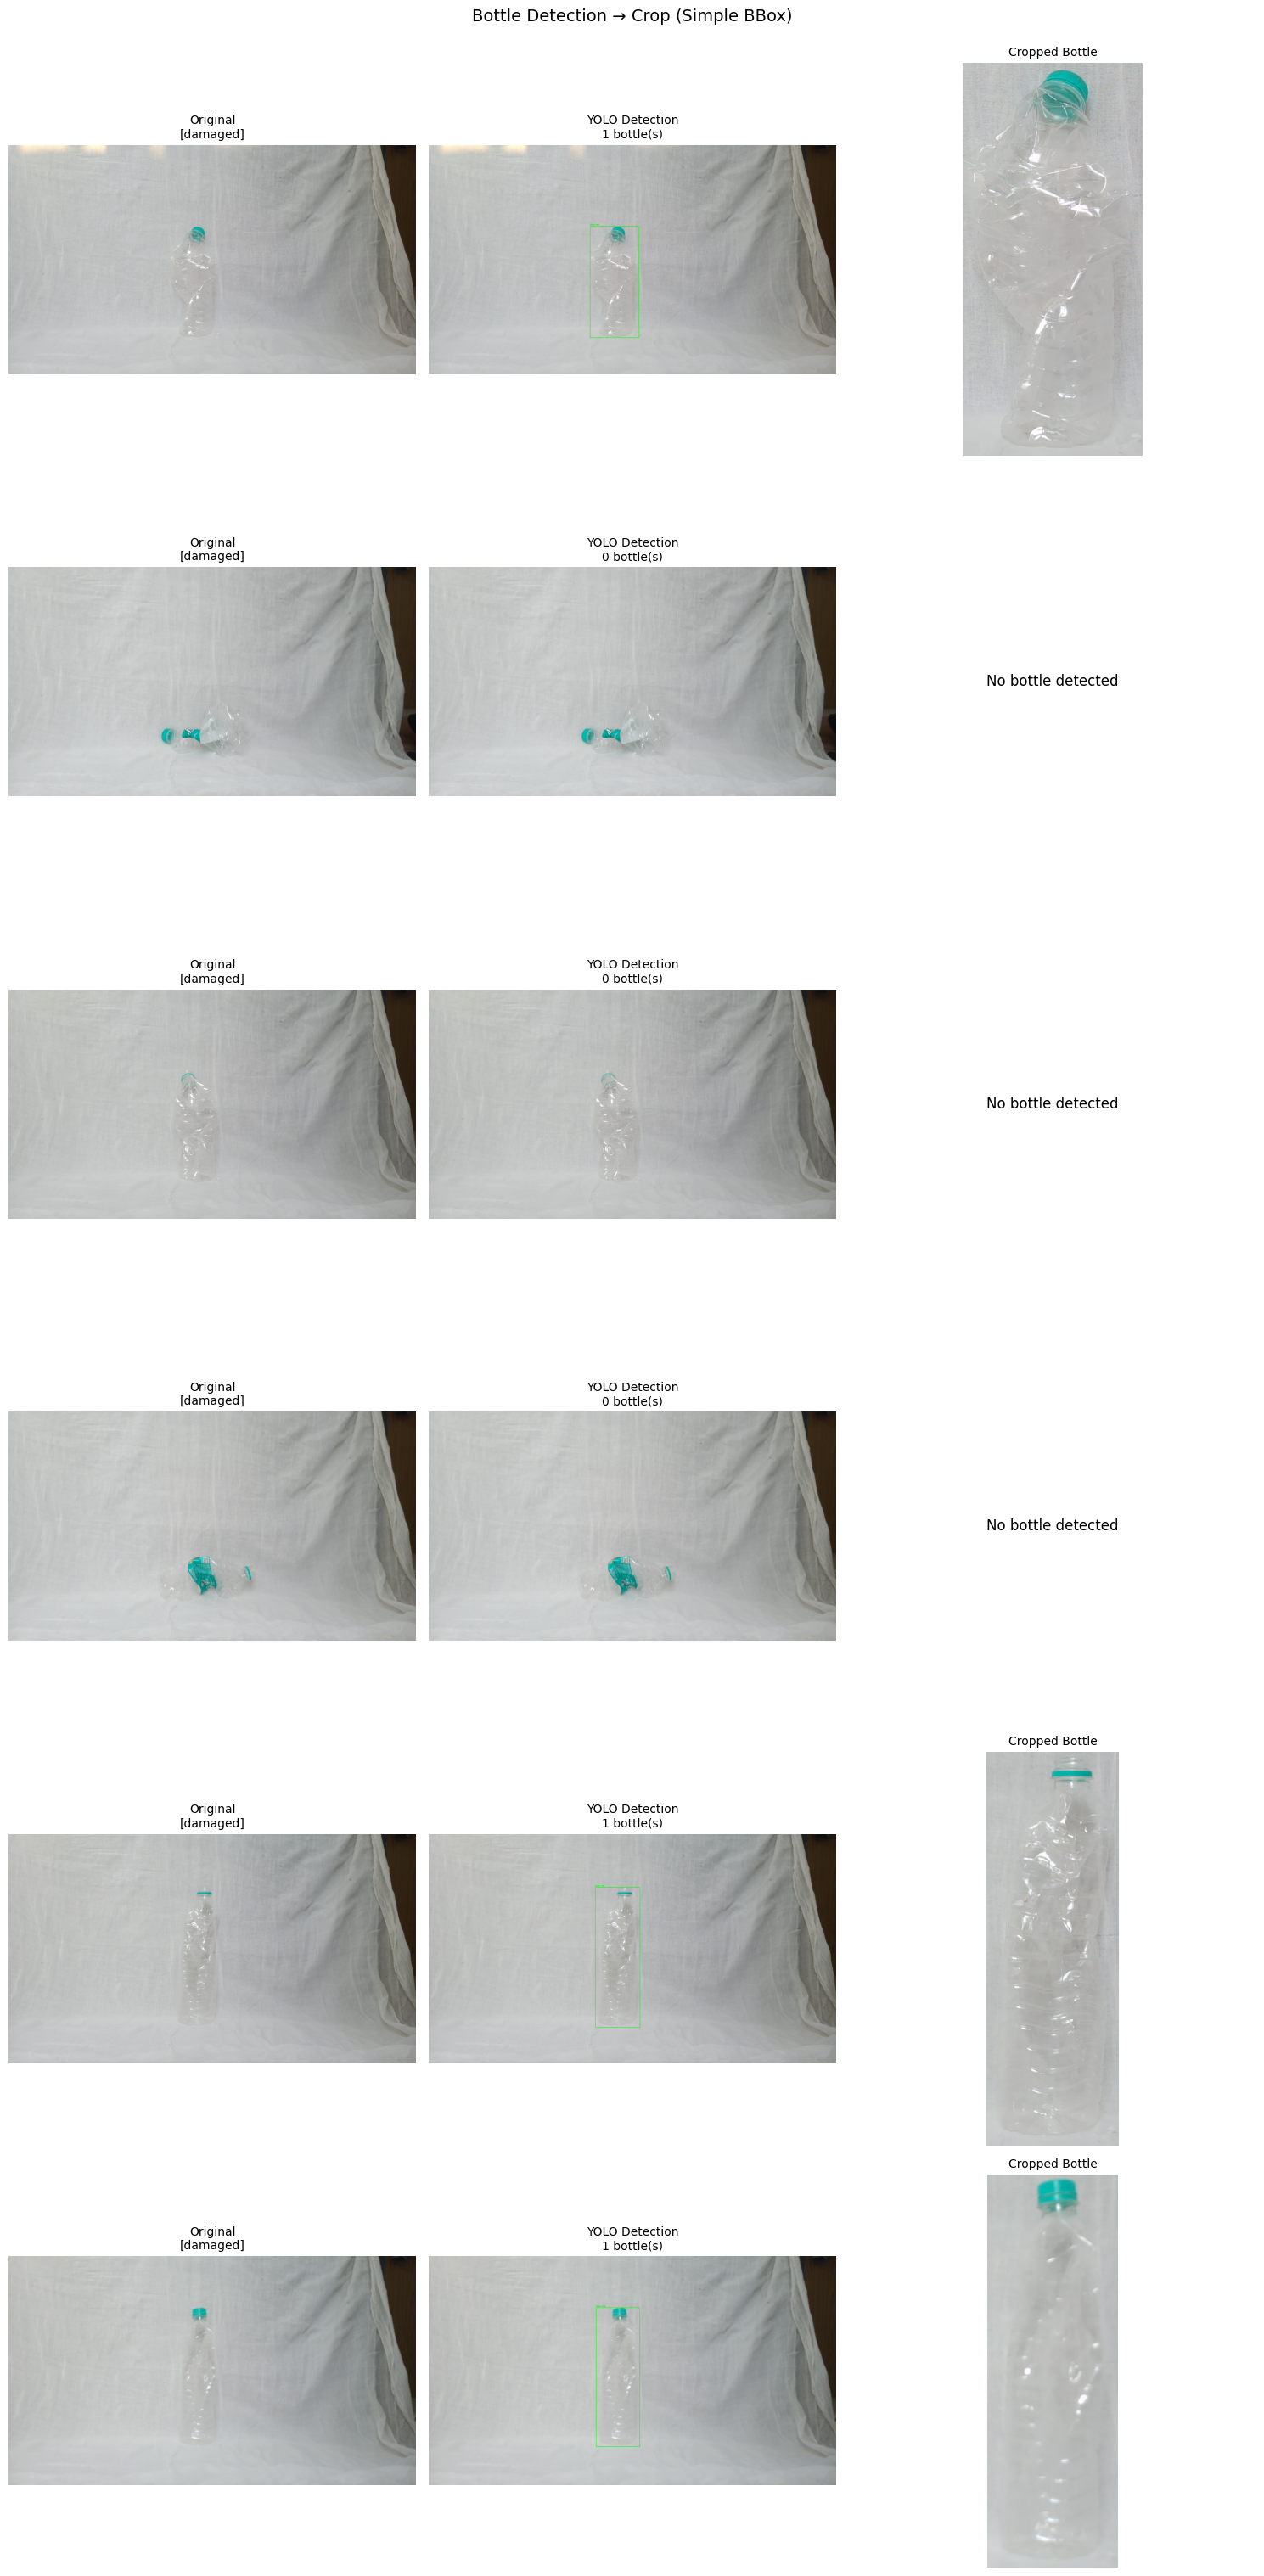


📊 Detected bottles in 3/6 sample images


In [10]:
# SIMPLIFIED: Just detect and crop using YOLO bounding box (no outline)
num_samples = min(6, len(all_images))
sample_images = all_images[:num_samples]

CONFIDENCE = 0.25
PADDING = 20  # Pixels to add around the bounding box

def detect_and_crop_simple(img_info, model, conf=0.25, padding=20):
    """
    Simple detection and cropping using YOLO bounding box only.
    No outline/contour detection - just crop the bbox region.
    """
    img_path = img_info['path']
    label = img_info['label']

    img = cv2.imread(img_path)
    if img is None:
        return None, None, [], label

    height, width = img.shape[:2]
    results = model(img, conf=conf, verbose=False)

    # Image with boxes drawn
    boxed_img = img.copy()
    crops = []

    for result in results:
        for box in result.boxes:
            cls_name = result.names[int(box.cls[0])]

            if cls_name == 'bottle':
                conf_score = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Draw bounding box (GREEN)
                cv2.rectangle(boxed_img, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(boxed_img, f"Bottle {conf_score:.0%}",
                           (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                           0.6, (0, 255, 0), 2)

                # Crop with padding
                crop_x1 = max(0, x1 - padding)
                crop_y1 = max(0, y1 - padding)
                crop_x2 = min(width, x2 + padding)
                crop_y2 = min(height, y2 + padding)

                cropped = img[crop_y1:crop_y2, crop_x1:crop_x2].copy()

                crops.append({
                    'image': cropped,
                    'confidence': conf_score,
                    'bbox': (x1, y1, x2, y2)
                })

    return img, boxed_img, crops, label


# Process and display
if sample_images:
    num_rows = len(sample_images)
    fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))

    if num_rows == 1:
        axes = axes.reshape(1, -1)

    for idx, img_info in enumerate(sample_images):
        original, boxed, crops, label = detect_and_crop_simple(img_info, model, CONFIDENCE, PADDING)

        if original is None:
            continue

        # Original
        axes[idx, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[idx, 0].set_title(f"Original\n[{label}]", fontsize=10)
        axes[idx, 0].axis('off')

        # With bounding box
        axes[idx, 1].imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
        axes[idx, 1].set_title(f"YOLO Detection\n{len(crops)} bottle(s)", fontsize=10)
        axes[idx, 1].axis('off')

        # Cropped
        if crops:
            crop_img = crops[0]['image']
            axes[idx, 2].imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
            axes[idx, 2].set_title(f"Cropped Bottle", fontsize=10)
        else:
            axes[idx, 2].text(0.5, 0.5, 'No bottle detected',
                             ha='center', va='center', fontsize=12)
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.suptitle('Bottle Detection → Crop (Simple BBox)', fontsize=14, y=1.01)
    plt.show()

    # Print detection stats
    detected = sum(1 for img_info in sample_images
                   for _ in [detect_and_crop_simple(img_info, model, CONFIDENCE, PADDING)]
                   if _[2])
    print(f"\n📊 Detected bottles in {detected}/{len(sample_images)} sample images")
else:
    print("❌ No images found!")

In [11]:
# ============================================
# TEST DETECTION ON ALL IMAGES
# ============================================

CONFIDENCE = 0.25  # Same low confidence that worked

total_images = len(all_images)
detected_images = 0
missed_images = []

print(f"🔄 Testing detection on {total_images} images...")
print(f"   Confidence threshold: {CONFIDENCE}\n")

for i, img_info in enumerate(all_images):
    img_path = img_info['path']
    label = img_info['label']

    img = cv2.imread(img_path)
    if img is None:
        continue

    results = model(img, conf=CONFIDENCE, verbose=False)

    # Check if bottle detected
    bottle_found = False
    for result in results:
        for box in result.boxes:
            if result.names[int(box.cls[0])] == 'bottle':
                bottle_found = True
                break

    if bottle_found:
        detected_images += 1
    else:
        missed_images.append({'path': img_path, 'label': label})

    # Progress
    if (i + 1) % 50 == 0 or (i + 1) == total_images:
        print(f"   Processed {i + 1}/{total_images} | Detected: {detected_images}")

# Summary
detection_rate = (detected_images / total_images) * 100

print(f"\n{'='*50}")
print(f"📊 DETECTION SUMMARY")
print(f"{'='*50}")
print(f"   Total images: {total_images}")
print(f"   Bottles detected: {detected_images}")
print(f"   Missed: {len(missed_images)}")
print(f"   Detection rate: {detection_rate:.1f}%")

# Breakdown by category
damaged_detected = sum(1 for img in all_images if img['label'] == 'damaged' and img not in missed_images)
damaged_total = len([img for img in all_images if img['label'] == 'damaged'])
not_damaged_detected = sum(1 for img in all_images if img['label'] == 'not_damaged' and img not in missed_images)
not_damaged_total = len([img for img in all_images if img['label'] == 'not_damaged'])

print(f"\n   By category:")
print(f"   - Damaged: {damaged_total - len([m for m in missed_images if m['label'] == 'damaged'])}/{damaged_total} detected")
print(f"   - Not Damaged: {not_damaged_total - len([m for m in missed_images if m['label'] == 'not_damaged'])}/{not_damaged_total} detected")

# Show missed images if any
if missed_images:
    print(f"\n⚠️ Missed images ({len(missed_images)}):")
    for m in missed_images[:10]:  # Show first 10
        print(f"   - [{m['label']}] {os.path.basename(m['path'])}")
    if len(missed_images) > 10:
        print(f"   ... and {len(missed_images) - 10} more")


# Try even lower confidence for the missed images
# CONFIDENCE_LOW = 0.05

# print("🔄 Re-checking missed images with lower confidence (0.05)...\n")

# recovered = []
# still_missed = []

# for m in missed_images:
#     img = cv2.imread(m['path'])
#     results = model(img, conf=CONFIDENCE_LOW, verbose=False)

#     bottle_found = False
#     for result in results:
#         for box in result.boxes:
#             if result.names[int(box.cls[0])] == 'bottle':
#                 bottle_found = True
#                 break

#     if bottle_found:
#         recovered.append(m)
#         print(f"   ✅ Recovered: {os.path.basename(m['path'])}")
#     else:
#         still_missed.append(m)
#         print(f"   ❌ Still missed: {os.path.basename(m['path'])}")

# print(f"\n📊 Results:")
# print(f"   Recovered: {len(recovered)}/9")
# print(f"   Still missed: {len(still_missed)}/9")

# if still_missed:
#     print(f"\n   New detection rate: {(117 + len(recovered))/126 * 100:.1f}%")


# # Visualize the missed bottles
# print("📷 Viewing the 9 missed bottles:\n")

# num_missed = len(still_missed)
# cols = 3
# rows = (num_missed + cols - 1) // cols

# fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
# axes = axes.flatten()

# for idx, m in enumerate(still_missed):
#     img = cv2.imread(m['path'])
#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     axes[idx].imshow(img_rgb)
#     axes[idx].set_title(f"{os.path.basename(m['path'])}\n[{m['label']}]", fontsize=10)
#     axes[idx].axis('off')

# # Hide empty subplots
# for idx in range(num_missed, len(axes)):
#     axes[idx].axis('off')

# plt.tight_layout()
# plt.suptitle('Missed Bottles - Not Detected by YOLO', fontsize=14, y=1.02)
# plt.show()

# print("\n💡 These bottles are likely too damaged/crushed to be recognized as bottles.")
# print("   Options:")
# print("   1. Proceed without them (93% coverage is good)")
# print("   2. Manually crop these 9 images")
# print("   3. Fine-tune YOLO to detect these specific cases")

🔄 Testing detection on 1071 images...
   Confidence threshold: 0.05

   Processed 50/1071 | Detected: 33
   Processed 100/1071 | Detected: 66
   Processed 150/1071 | Detected: 103
   Processed 200/1071 | Detected: 133
   Processed 250/1071 | Detected: 165
   Processed 300/1071 | Detected: 197
   Processed 350/1071 | Detected: 230
   Processed 400/1071 | Detected: 266
   Processed 450/1071 | Detected: 301
   Processed 500/1071 | Detected: 335
   Processed 550/1071 | Detected: 363
   Processed 600/1071 | Detected: 397
   Processed 650/1071 | Detected: 431
   Processed 700/1071 | Detected: 465
   Processed 750/1071 | Detected: 499
   Processed 800/1071 | Detected: 529
   Processed 850/1071 | Detected: 561
   Processed 900/1071 | Detected: 601
   Processed 950/1071 | Detected: 651
   Processed 1000/1071 | Detected: 700
   Processed 1050/1071 | Detected: 750
   Processed 1071/1071 | Detected: 771

📊 DETECTION SUMMARY
   Total images: 1071
   Bottles detected: 771
   Missed: 300
   Detection

## Step 6: Show Detailed Pipeline for One Image

📷 Processing: bottle_164t 2.jpg
   Label: damaged


KeyboardInterrupt: 

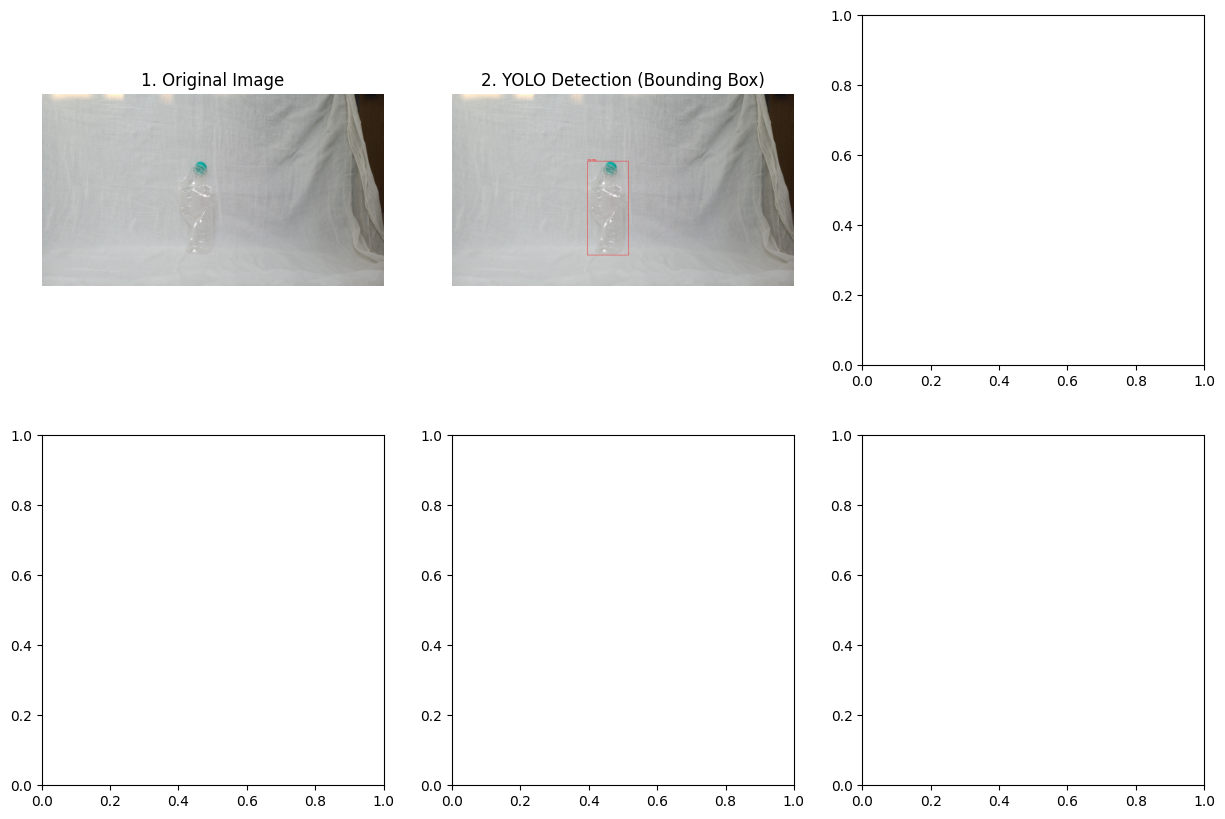

In [12]:
# Show detailed outline process for one image
if all_images:
    test_img_info = all_images[0]
    img = cv2.imread(test_img_info['path'])

    print(f"📷 Processing: {os.path.basename(test_img_info['path'])}")
    print(f"   Label: {test_img_info['label']}")

    # Detect
    results = model(img, conf=CONFIDENCE, verbose=False)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Original
    axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('1. Original Image')
    axes[0, 0].axis('off')

    # Process first detected bottle
    bottle_found = False
    for result in results:
        for box in result.boxes:
            if result.names[int(box.cls[0])] == 'bottle' and not bottle_found:
                bottle_found = True
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                bbox = (x1, y1, x2, y2)

                # 2. YOLO Detection (bbox)
                bbox_img = img.copy()
                cv2.rectangle(bbox_img, (x1, y1), (x2, y2), (0, 0, 255), 3)
                cv2.putText(bbox_img, 'YOLO BBox', (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                axes[0, 1].imshow(cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB))
                axes[0, 1].set_title('2. YOLO Detection (Bounding Box)')
                axes[0, 1].axis('off')

                # 3. Get mask
                mask = get_bottle_mask_grabcut(img, bbox)
                axes[0, 2].imshow(mask * 255, cmap='gray')
                axes[0, 2].set_title('3. GrabCut Segmentation Mask')
                axes[0, 2].axis('off')

                # 4. Get contour and draw outline
                contour, _ = get_bottle_contour(img, bbox)
                contour_img = img.copy()
                cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 3)
                axes[1, 0].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
                axes[1, 0].set_title('4. Bottle Outline (Green Contour)')
                axes[1, 0].axis('off')

                # 5. Cropped with background removed
                cropped, crop_mask = crop_bottle_with_contour(img, contour, mask, padding=15)
                axes[1, 1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
                axes[1, 1].set_title('5. Cropped (White Background)')
                axes[1, 1].axis('off')

                # 6. Just the mask of cropped region
                axes[1, 2].imshow(crop_mask * 255, cmap='gray')
                axes[1, 2].set_title('6. Crop Mask')
                axes[1, 2].axis('off')

    if not bottle_found:
        print("❌ No bottle detected in this image!")
        print("   Try lowering the CONFIDENCE threshold.")
        for ax in axes.flatten()[1:]:
            ax.text(0.5, 0.5, 'No bottle detected', ha='center', va='center')
            ax.axis('off')

    plt.tight_layout()
    plt.suptitle('Complete Outline Detection Pipeline', fontsize=14, y=1.02)
    plt.show()

## Step 7: Process ALL Images

In [ ]:
import shutil

# Create output directories (maintaining structure)
output_base = "processed_bottles"
outlined_dir = os.path.join(output_base, "outlined")
cropped_dir = os.path.join(output_base, "cropped")

# Clean up if exists
if os.path.exists(output_base):
    shutil.rmtree(output_base)

for folder in ['damaged', 'not_damaged']:
    os.makedirs(os.path.join(outlined_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(cropped_dir, folder), exist_ok=True)

print(f"📁 Output structure:")
print(f"   {output_base}/")
print(f"   ├── outlined/")
print(f"   │   ├── damaged/")
print(f"   │   └── not_damaged/")
print(f"   └── cropped/")
print(f"       ├── damaged/")
print(f"       └── not_damaged/")

In [ ]:
# Process all images
CONFIDENCE = 0.25  # Detection confidence
PADDING = 15       # Padding around cropped bottles

results_summary = {
    'damaged': {'images': 0, 'bottles': 0},
    'not_damaged': {'images': 0, 'bottles': 0}
}

crop_id = 0
failed_images = []
no_detection_images = []

print(f"🔄 Processing {len(all_images)} images...")
print(f"   Confidence threshold: {CONFIDENCE}")
print()

for i, img_info in enumerate(all_images):
    img_path = img_info['path']
    label = img_info['label']

    # Read image
    img = cv2.imread(img_path)
    if img is None:
        failed_images.append(img_path)
        continue

    # Run YOLO
    detections = model(img, conf=CONFIDENCE, verbose=False)

    # Process each detection
    outlined_img = img.copy()
    bottle_count = 0

    for result in detections:
        for box in result.boxes:
            cls_name = result.names[int(box.cls[0])]

            if cls_name == 'bottle':
                conf = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                bbox = (x1, y1, x2, y2)

                try:
                    # Get contour
                    contour, mask = get_bottle_contour(img, bbox)

                    # Draw outline
                    cv2.drawContours(outlined_img, [contour], -1, (0, 255, 0), 2)

                    # Crop
                    cropped, _ = crop_bottle_with_contour(img, contour, mask, padding=PADDING)

                    # Save cropped bottle
                    crop_filename = f"bottle_{crop_id:05d}.png"
                    crop_path = os.path.join(cropped_dir, label, crop_filename)
                    cv2.imwrite(crop_path, cropped)

                    crop_id += 1
                    bottle_count += 1

                except Exception as e:
                    # Fallback: simple bbox crop
                    y1_safe = max(0, y1)
                    y2_safe = min(img.shape[0], y2)
                    x1_safe = max(0, x1)
                    x2_safe = min(img.shape[1], x2)

                    cropped = img[y1_safe:y2_safe, x1_safe:x2_safe]
                    if cropped.size > 0:
                        crop_filename = f"bottle_{crop_id:05d}.png"
                        crop_path = os.path.join(cropped_dir, label, crop_filename)
                        cv2.imwrite(crop_path, cropped)
                        crop_id += 1
                        bottle_count += 1

    # Save outlined image if bottles found
    if bottle_count > 0:
        outline_filename = f"outlined_{Path(img_path).stem}.jpg"
        outline_path = os.path.join(outlined_dir, label, outline_filename)
        cv2.imwrite(outline_path, outlined_img)
    else:
        no_detection_images.append(img_path)

    # Update summary
    results_summary[label]['images'] += 1
    results_summary[label]['bottles'] += bottle_count

    # Progress
    if (i + 1) % 20 == 0 or (i + 1) == len(all_images):
        print(f"  Processed {i + 1}/{len(all_images)} | Bottles cropped: {crop_id}")

print(f"\n✅ Processing complete!")
print(f"\n📊 Summary:")
print(f"   Damaged:")
print(f"     Images processed: {results_summary['damaged']['images']}")
print(f"     Bottles cropped: {results_summary['damaged']['bottles']}")
print(f"   Not Damaged:")
print(f"     Images processed: {results_summary['not_damaged']['images']}")
print(f"     Bottles cropped: {results_summary['not_damaged']['bottles']}")
print(f"\n   Total bottles: {crop_id}")

if no_detection_images:
    print(f"\n⚠️ No bottles detected in {len(no_detection_images)} images")
    print(f"   (Try lowering CONFIDENCE threshold)")

if failed_images:
    print(f"\n❌ Failed to read {len(failed_images)} images")

## Step 8: View Results

---

## ✅ Output Summary

| File | Contents |
|------|----------|
| `cropped_bottles.zip` | Individual bottle crops with background removed, organized by damaged/not_damaged |
| `outlined_bottles.zip` | Original images with green outlines drawn around detected bottles |

**Folder structure:**
```
cropped_bottles/
├── damaged/
│   ├── bottle_00001.png  ← Cropped bottle, white background
│   └── ...
└── not_damaged/
    ├── bottle_00050.png
    └── ...
```

These cropped bottles are ready for your **damage detection model**!

In [13]:
# ============================================
# STEP 2: CREATE TRAINING DATASET
# ============================================
import os
import shutil
import random
from pathlib import Path

dataset_dir = "/content/bottle_finetune"
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)

for split in ['train', 'val']:
    os.makedirs(f"{dataset_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{dataset_dir}/{split}/labels", exist_ok=True)

CONFIDENCE = 0.10
successful_labels = 0
manual_labels = 0

# Process all images
all_paths = [img['path'] for img in all_images]
random.shuffle(all_paths)

# 80/20 split
split_idx = int(len(all_paths) * 0.8)
train_paths = all_paths[:split_idx]
val_paths = all_paths[split_idx:]

missed_paths = [m['path'] for m in missed_images]

def create_label(img_path, label_path):
    """Create YOLO format label for an image."""
    global successful_labels, manual_labels

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Check if this is a missed image
    is_missed = img_path in missed_paths

    if not is_missed:
        # Auto-detect with YOLO
        results = model(img, conf=CONFIDENCE, verbose=False)

        for result in results:
            for box in result.boxes:
                if result.names[int(box.cls[0])] == 'bottle':
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

                    # YOLO format: class x_center y_center width height (normalized)
                    x_center = ((x1 + x2) / 2) / w
                    y_center = ((y1 + y2) / 2) / h
                    box_w = (x2 - x1) / w
                    box_h = (y2 - y1) / h

                    with open(label_path, 'w') as f:
                        f.write(f"0 {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}\n")
                    successful_labels += 1
                    return True

    # For missed images OR if detection failed: assume bottle is centered
    # These bottles fill most of the frame based on your images
    with open(label_path, 'w') as f:
        f.write(f"0 0.50 0.52 0.45 0.90\n")  # Centered, takes most of frame
    manual_labels += 1
    return True

# Process train set
print("🔄 Creating training labels...")
for i, img_path in enumerate(train_paths):
    filename = Path(img_path).stem
    shutil.copy(img_path, f"{dataset_dir}/train/images/{filename}.jpg")
    create_label(img_path, f"{dataset_dir}/train/labels/{filename}.txt")

    if (i + 1) % 30 == 0:
        print(f"   Train: {i + 1}/{len(train_paths)}")

# Process val set
print("🔄 Creating validation labels...")
for img_path in val_paths:
    filename = Path(img_path).stem
    shutil.copy(img_path, f"{dataset_dir}/val/images/{filename}.jpg")
    create_label(img_path, f"{dataset_dir}/val/labels/{filename}.txt")

# Create data.yaml
yaml_content = f"""path: {dataset_dir}
train: train/images
val: val/images

names:
  0: bottle

nc: 1
"""

with open(f"{dataset_dir}/data.yaml", 'w') as f:
    f.write(yaml_content)

print(f"\n✅ Dataset created!")
print(f"   Auto-labeled: {successful_labels}")
print(f"   Manual/fallback labels: {manual_labels}")
print(f"   Train images: {len(train_paths)}")
print(f"   Val images: {len(val_paths)}")

🔄 Creating training labels...
   Train: 30/856
   Train: 60/856
   Train: 90/856
   Train: 120/856
   Train: 150/856
   Train: 180/856
   Train: 210/856
   Train: 240/856
   Train: 270/856
   Train: 300/856
   Train: 330/856
   Train: 360/856
   Train: 390/856
   Train: 420/856
   Train: 450/856
   Train: 480/856
   Train: 510/856
   Train: 540/856
   Train: 570/856
   Train: 600/856
   Train: 630/856
   Train: 660/856
   Train: 690/856
   Train: 720/856
   Train: 750/856
   Train: 780/856
   Train: 810/856
   Train: 840/856
🔄 Creating validation labels...

✅ Dataset created!
   Auto-labeled: 700
   Manual/fallback labels: 371
   Train images: 856
   Val images: 215


In [14]:
# ============================================
# STEP 3: FINE-TUNE YOLO
# ============================================
from ultralytics import YOLO

# Start from pre-trained model
model_ft = YOLO('yolov8n.pt')  # Using 'small' for better accuracy

print("🚀 Fine-tuning YOLO on your bottles...")
print("   This takes ~10-20 minutes on Colab GPU\n")

results = model_ft.train(
    data=f"{dataset_dir}/data.yaml",
    epochs=71,
    imgsz=640,
    batch=16,
    patience=5,        # Stop if no improvement for 15 epochs
    device=0,           # GPU
    workers=2,
    name='bottle_finetuned',
    exist_ok=True,
    pretrained=True,
    lr0=0.001,          # Lower learning rate for fine-tuning
    lrf=0.01,
)

print("\n✅ Fine-tuning complete!")

🚀 Fine-tuning YOLO on your bottles...
   This takes ~10-20 minutes on Colab GPU

New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/bottle_finetune/data.yaml, epochs=71, time=None, patience=5, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=None, name=bottle_finetuned, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augmen

100%|██████████| 755k/755k [00:00<00:00, 21.1MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


...


14 epochs completed in 0.251 hours.
Optimizer stripped from runs/detect/bottle_finetuned/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/bottle_finetuned/weights/best.pt, 6.2MB

Validating runs/detect/bottle_finetuned/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  14%|█▍        | 1/7 [00:00<00:01,  3.29it/s]Exception in thread Thread-39 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 909, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _s

                   all        205        205      0.873      0.839      0.907      0.831
Speed: 0.2ms preprocess, 1.7ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/bottle_finetuned


lr/pg0,▁▅████▇▇▇▇▇▇▇▆
lr/pg1,▁▅████▇▇▇▇▇▇▇▆
lr/pg2,▁▅████▇▇▇▇▇▇▇▆
metrics/mAP50(B),▃▁▃▁▄▃▇██▄▃█▃█
metrics/mAP50-95(B),▂▁▂▁▃▂▆▇█▅▄█▄█
metrics/precision(B),█▂▄▇▆▄▆▄█▃▁▃██
metrics/recall(B),▁▃▆▁▄▆▇█▇▄▅█▃▇
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



✅ Fine-tuning complete!


In [15]:
# ============================================
# STEP 4: TEST FINE-TUNED MODEL
# ============================================

# Load fine-tuned model
model = YOLO('/content/runs/detect/bottle_finetuned/weights/best.pt')
print("✅ Loaded fine-tuned model!")

# Test on previously missed images
print("\n🔄 Testing on previously missed images...\n")

CONFIDENCE = 0.25  # Can use higher confidence now

for m in missed_images:
    img = cv2.imread(m['path'])
    results = model(img, conf=CONFIDENCE, verbose=False)

    bottle_found = False
    for result in results:
        for box in result.boxes:
            if result.names[int(box.cls[0])] == 'bottle':
                bottle_found = True
                break

    status = "✅ DETECTED" if bottle_found else "❌ Still missed"
    print(f"   {status}: {os.path.basename(m['path'])}")

# Test on all images
print("\n🔄 Testing on ALL images...")
detected = 0
for img_info in all_images:
    img = cv2.imread(img_info['path'])
    results = model(img, conf=CONFIDENCE, verbose=False)

    for result in results:
        for box in result.boxes:
            if result.names[int(box.cls[0])] == 'bottle':
                detected += 1
                break

print(f"\n📊 Final Detection Rate: {detected}/{len(all_images)} ({detected/len(all_images)*100:.1f}%)")

✅ Loaded fine-tuned model!

🔄 Testing on previously missed images...

   ✅ DETECTED: bottle_100t.jpg
   ✅ DETECTED: bottle_113t 2.jpg
   ✅ DETECTED: bottle_65t.jpg
   ✅ DETECTED: bottle_187t 2.jpg
   ✅ DETECTED: bottle_47t.jpg
   ✅ DETECTED: bottle_281t.jpg
   ✅ DETECTED: bottle_93t 2.jpg
   ✅ DETECTED: bottle_155t.jpg
   ✅ DETECTED: bottle_101t 2.jpg
   ✅ DETECTED: bottle_218t.jpg
   ✅ DETECTED: bottle_214t.jpg
   ✅ DETECTED: bottle_116t 2.jpg
   ✅ DETECTED: bottle_15t 2.jpg
   ✅ DETECTED: bottle_61t 2.jpg
   ✅ DETECTED: bottle_73t.jpg
   ✅ DETECTED: bottle_117t.jpg
   ✅ DETECTED: bottle_145t.jpg
   ✅ DETECTED: bottle_286t.jpg
   ✅ DETECTED: bottle_60t 2.jpg
   ✅ DETECTED: bottle_105t.jpg
   ✅ DETECTED: bottle_0t.jpg
   ✅ DETECTED: bottle_55t.jpg
   ✅ DETECTED: bottle_179t 2.jpg
   ✅ DETECTED: bottle_11t 2.jpg
   ✅ DETECTED: bottle_166t.jpg
   ✅ DETECTED: bottle_175t.jpg
   ✅ DETECTED: bottle_114t 2.jpg
   ✅ DETECTED: bottle_56t.jpg
   ✅ DETECTED: bottle_91t.jpg
   ✅ DETECTED: bottle_